In [40]:
import sys
import os
import csv

# Add parent and grandparent directories to sys.path
sys.path.insert(0, '..')
sys.path.insert(0, '../..')

import numpy as np
from scipy import linalg
from scipy.linalg import expm
from scipy.stats import qmc

import math

import matplotlib.pyplot as plt
import seaborn as sns

import random

FIGURES_FILEPATH = '../QuNet_bootcamp_2025/Session_7/NM_figures/'

# Deterministic

In [4]:
def generate_seq_rules_deterministic(gates = ['j','g'],rule_len = 2):
    '''
    Generate rules for generating sequence based on previous two steps (deterministic).
    '''

    gate_seqs = [()]
    for i in range(rule_len):
        gate_seqs = [x + tuple(g) for x in gate_seqs for g in gates] # TODO: generalize to longer patterns 

    gate_dests = [[]]
    for i in range(len(gate_seqs)):
        gate_dests = [x + [g] for x in gate_dests for g in gates]

    two_gram_rules = []
    for dests in gate_dests: 
        rule = {key: value for key, value in zip(gate_seqs, dests)} 
        two_gram_rules.append(rule)

    return two_gram_rules, gate_seqs

two_gram_rules_det, two_gate_seqs = generate_seq_rules_deterministic(rule_len = 2)
three_gram_rules_det, three_gate_seqs = generate_seq_rules_deterministic(rule_len = 3)
two_gram_rules_det

[{('j', 'j'): 'j', ('j', 'g'): 'j', ('g', 'j'): 'j', ('g', 'g'): 'j'},
 {('j', 'j'): 'j', ('j', 'g'): 'j', ('g', 'j'): 'j', ('g', 'g'): 'g'},
 {('j', 'j'): 'j', ('j', 'g'): 'j', ('g', 'j'): 'g', ('g', 'g'): 'j'},
 {('j', 'j'): 'j', ('j', 'g'): 'j', ('g', 'j'): 'g', ('g', 'g'): 'g'},
 {('j', 'j'): 'j', ('j', 'g'): 'g', ('g', 'j'): 'j', ('g', 'g'): 'j'},
 {('j', 'j'): 'j', ('j', 'g'): 'g', ('g', 'j'): 'j', ('g', 'g'): 'g'},
 {('j', 'j'): 'j', ('j', 'g'): 'g', ('g', 'j'): 'g', ('g', 'g'): 'j'},
 {('j', 'j'): 'j', ('j', 'g'): 'g', ('g', 'j'): 'g', ('g', 'g'): 'g'},
 {('j', 'j'): 'g', ('j', 'g'): 'j', ('g', 'j'): 'j', ('g', 'g'): 'j'},
 {('j', 'j'): 'g', ('j', 'g'): 'j', ('g', 'j'): 'j', ('g', 'g'): 'g'},
 {('j', 'j'): 'g', ('j', 'g'): 'j', ('g', 'j'): 'g', ('g', 'g'): 'j'},
 {('j', 'j'): 'g', ('j', 'g'): 'j', ('g', 'j'): 'g', ('g', 'g'): 'g'},
 {('j', 'j'): 'g', ('j', 'g'): 'g', ('g', 'j'): 'j', ('g', 'g'): 'j'},
 {('j', 'j'): 'g', ('j', 'g'): 'g', ('g', 'j'): 'j', ('g', 'g'): 'g'},
 {('j'

In [65]:
two_gate_seqs

[('j', 'j'), ('j', 'g'), ('g', 'j'), ('g', 'g')]

In [5]:
def generate_seq_from_rule_det(rule : dict, init : list, max_steps : int):
    '''
    Generate gate sequences given a rule. 

    Parameters
    ----------
    rule : dictionary where keys correspond to previous pattern to match, values
            correspond to next element of sequence to generate. 
    init : initial list of gates to start from. 
    gates : list of all gates. 
    '''

    # check that all keys in rule are of equal length
    pattern_len = len(list(rule.keys())[0])
    for key in rule.keys():
        if len(key) != pattern_len:
            raise Exception('Length of pattern to match is not equal.')
    
    # check that initial sequence is at least as long as pattern-to-match
    if len(init) < pattern_len:
        raise Exception('Initial string must be greater or equal to pattern length.')

    # generate new sequence based on rule
    pattern_prev = tuple(init[-pattern_len:])
    gen_seq = init.copy()

    for i in range(max_steps): 
        gen_seq.append(rule[pattern_prev])
        pattern_prev = tuple(gen_seq[-pattern_len:])
    
    return gen_seq

In [6]:
def principal_period(inputv):
    if not inputv:
        return inputv

    nxt = [0]*len(inputv)
    for i in range(1, len(nxt)):
        k = nxt[i - 1]
        while True:
            if inputv[i] == inputv[k]:
                nxt[i] = k + 1
                break
            elif k == 0:
                nxt[i] = 0
                break
            else:
                k = nxt[k - 1]

    smallPieceLen = len(inputv) - nxt[-1]
    if len(inputv) % smallPieceLen != 0:
        return inputv

    return inputv[0:smallPieceLen]

In [7]:
def find_interesting_rules(init_seq, rules, printing=True):
    n_pattern = len(list(rules[0].keys())[0])
    interesting_rules = []
    patterns = []
    for i in range(len(rules)): 
        seq = generate_seq_from_rule_det(rule = rules[i], init = init_seq, max_steps = 50)
        combined_str = ''.join(seq)
        pattern = principal_period(combined_str[-3 * math.factorial(n_pattern):])
        if len(pattern) > n_pattern:
            interesting_rules.append(i)
            patterns.append(pattern) 
            if printing: 
                print(f'{i}: {combined_str}')
    
    return interesting_rules, patterns

In [8]:
for seq in two_gate_seqs:
    init_seq = list(seq)
    idx, patts = find_interesting_rules(init_seq, two_gram_rules_det,printing=False)
    print(idx, patts)
    if seq == two_gate_seqs[0]: 
        res = idx
    res = list(set(res) & set(idx))

res

[8, 9, 12, 14] ['jgj', 'jgj', 'ggjjgg', 'jgg']
[6, 8, 9, 12, 14] ['ggj', 'gjj', 'gjj', 'gjjggj', 'ggj']
[6, 8, 9, 12, 14] ['jgg', 'jjg', 'jjg', 'jggjjg', 'jgg']
[6, 8, 12, 14] ['gjg', 'gjj', 'jjggjj', 'gjg']


[8, 12, 14]

In [9]:
for seq in three_gate_seqs:
    init_seq = list(seq)
    idx, patts = find_interesting_rules(init_seq, three_gram_rules_det,printing=False)
    print(idx, patts)
    if seq == three_gate_seqs[0]: 
        res = idx
    res = list(set(res) & set(idx))

[128, 129, 130, 131, 132, 133, 134, 135, 144, 145, 146, 147, 148, 149, 150, 151, 164, 165, 172, 173, 180, 182, 188, 190, 192, 193, 194, 195, 196, 197, 200, 201, 202, 203, 204, 205, 208, 210, 212, 214, 216, 218, 220, 222, 224, 225, 228, 229, 232, 233, 236, 237, 240, 244, 246, 248, 252, 254] ['gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'gjjjgjjjgjjjgjjjgj', 'jjjgjggjjjgjggjjjg', 'jjjgjggjjjgjggjjjg', 'ggjjgj', 'ggjjgj', 'gjgggjjjgjgggjjjgj', 'gjgggjgggjgggjgggj', 'gjjgjgggjjgjgggjjg', 'gjgggjgggjgggjgggj', 'jjjggjjjggjjjggjjj', 'jjjggjjjggjjjggjjj', 'jjjggjgjjjggjgjjjg', 'jjjggjgjjjggjgjjjg', 'jjjggjjjggjjjggjjj', 'jjjggjjjggjjjggjjj', 'ggjjggjjggjjggjjgg', 'ggjjggjjggjjggjjgg', 'jgjjgg', 'jgjjgg', 'ggjjggj

# Probabilistic

In [10]:
probabilities = [0.05, 0.3, 0.5, 0.95]

def generate_seq_rules_prob(probabilities, gates = ['j','g'], rule_len = 2):
    '''
    Generate rules for generating sequence based on previous two steps (probabilistic).
    '''
    # names for each probability
    prob_names = {x: str(i) for i, x in enumerate(probabilities)} 

    # generate all possible gate sequence patterns 
    gate_seqs = [()]
    for i in range(rule_len):
        gate_seqs = [x + tuple(g) for x in gate_seqs for g in gates] # TODO: generalize to longer patterns 

    # generate all possible values to map to 
    gate_dests = [[]]
    for i in range(len(gate_seqs)):
        gate_dests = [x + [g] for x in gate_dests for g in probabilities]

    # create dict of dict of all rules (one dict = one rule family) 
    two_gram_rules = {} 
    for dests in gate_dests: 
        name = 'rule_'+'_'.join([prob_names[x] for x in dests])
        rule = {key: value for key, value in zip(gate_seqs, dests)} 
        two_gram_rules[name] = rule

    return two_gram_rules, gate_seqs

two_gram_rules_prob, two_gate_seqs = generate_seq_rules_prob(probabilities = probabilities, rule_len = 2)
two_gram_rules_prob

{'rule_0_0_0_0': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.05,
  ('g', 'g'): 0.05},
 'rule_0_0_0_1': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.05,
  ('g', 'g'): 0.3},
 'rule_0_0_0_2': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.05,
  ('g', 'g'): 0.5},
 'rule_0_0_0_3': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.05,
  ('g', 'g'): 0.95},
 'rule_0_0_1_0': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.3,
  ('g', 'g'): 0.05},
 'rule_0_0_1_1': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.3,
  ('g', 'g'): 0.3},
 'rule_0_0_1_2': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.3,
  ('g', 'g'): 0.5},
 'rule_0_0_1_3': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.3,
  ('g', 'g'): 0.95},
 'rule_0_0_2_0': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.5,
  ('g', 'g'): 0.05},
 'rule_0_0_2_1': {('j', 'j'): 0.05,
  ('j', 'g'): 0.05,
  ('g', 'j'): 0.5,
  ('g', 'g'): 0.3},
 'rule_0_0_2_2': {('j', 'j'): 0.05,
  ('j

In [67]:
two_gram_rules_prob['rule_1_3_1_3']

{('j', 'j'): 0.3, ('j', 'g'): 0.95, ('g', 'j'): 0.3, ('g', 'g'): 0.95}

In [11]:
def generate_seq_from_rule_prob(rule : dict, init : list, max_steps : int, 
                                gates = ['j','g'],seed = None):
    '''
    Generate gate sequences given a probabilistic rule. 

    Parameters
    ----------
    rule : dictionary where keys correspond to previous pattern to match, values
            correspond to probability p of gate_1 to generate, such that gate_2
            has probability 1 - p to generate. 
    init : initial list of gates to start from. 
    max_steps : maximum number of steps to run for. 
    gates : list of all gates. 
    seed : None or int, the random seed to set. 

    Returns
    -------
    str, generated sequence of gates. 
    '''

    # check that all keys in rule are of equal length
    pattern_len = len(list(rule.keys())[0])
    
    # check that initial sequence is at least as long as pattern-to-match
    if len(init) < pattern_len:
        raise Exception('Initial string must be greater or equal to pattern length.')

    # generate new sequence based on rule
    pattern_prev = tuple(init[-pattern_len:]) # get previous pattern to match
    gen_seq = init.copy() 

    for i in range(max_steps): 
        # get probability of gate 1 
        prob = rule[pattern_prev] 
        # select next gate based on probability
        next_gate = random.choices(gates, weights=[prob, 1.0-prob])[0] 
        gen_seq.append(next_gate)

        pattern_prev = tuple(gen_seq[-pattern_len:])
    
    # concat gen_seq into one string (no spaces)
    gen_seq = ''.join(gen_seq)
    
    return gen_seq

With 4 probabilities, and 4 mapping within each rule, we will get a total of $4^4 = 256$ possible rules. We will use Latin Hypercube Sampling to work with a subset of these rules. 

In [12]:
def lhs_sample_probabilities(num_samples : int, num_possible_gate_seq : int, num_probs : int): 
    '''
    Generate Latin Hypercube Sampling of our probabilistic rules.

    Parameters
    ----------
    num_samples : int, how many samples to choose
    num_possible_gate : int, total number of possible gates for this configuration. 
        i.e., for 2 gates 2-gram, we have a total of 4 possible gate seqs. 
    num_probs : int, number of probabilities we are working with. 

    Returns
    -------
    names : list of string names (i.e. 'rule0_1_2_1') of rules
    '''
    # create a Latin Hypercube sampler
    # setting dim d=possible_gates as this is how many "factors" we have
    sampler = qmc.LatinHypercube(d=num_possible_gate_seq) 

    # generate the samples
    sample = sampler.random(n=num_samples)

    # convert sample values into one of each probability 
    num_probs = len(probabilities) 
    convert_to_prob_name = np.vectorize(lambda x: str(int(math.floor(x * num_probs))))
    names = ['rule_'+'_'.join(x) for x in convert_to_prob_name(sample)]

    return names

In [13]:
def lhs_sample_generation(num_samples : int, 
                            gen_seq_len : int, 
                            gen_per_rule : int, 
                            gate_seqs : list, 
                            num_probabilities : int,
                            folder_name = 'non_markovian_orders_list'): 
    '''
    Using Latin Hypercube Sampling (LHS) of our rules, generate sequences of gates. 
    All sequences generated for each rule are saved in a .csv file. 

    Parameters
    ----------
    num_samples : int, number of samples to draw.
    gen_seq_len : int, number of gates to generate in each sequence. 
    gen_per_rule : int, how many trials to run for each rule. 
    gate_seqs : all possible gate sequences of our rules. 
    num_probabilities : number of probabilities we consider. 
    folder_name : name of folder to save to. 
    '''
    
    gen_per_init_seq = int(gen_per_rule / len(gate_seqs)) # how many times to generate for each initial gate seq

    rule_names = lhs_sample_probabilities(num_samples, len(gate_seqs), num_probabilities)

    for name in rule_names:
        rule = two_gram_rules_prob[name] # obtain rule 
        list_seq = []
        
        for i in range(len(gate_seqs)):
            init_seq = list(gate_seqs[i])
            
            for j in range(gen_per_init_seq): 
                seq = generate_seq_from_rule_prob(rule = rule, init = init_seq, max_steps = gen_seq_len)
                list_seq.append(seq)
                
        
        file_name = f'../{folder_name}/{name}.csv'
        with open(file_name, "w") as file:
            file.write(",\n".join(list_seq))

num_samples = 25 # how many rules to sample
gen_seq_len = 500 # length of seq strings to generate 
gen_per_rule = 100 # how many times to generate strings for each distinct rule

lhs_sample_generation(num_samples = num_samples,
                        gen_seq_len = gen_seq_len,
                        gen_per_rule = gen_per_rule,
                        gate_seqs = two_gate_seqs,
                        num_probabilities = len(probabilities))

# Gate probabilities

In [14]:
# specify rules for which we want to check
NM_orders_names = ['0_0_2_2', '2_0_2_3', '1_3_1_3', '3_3_2_2', '3_3_3_3']
NM_orders_dict = {} 

# open all the files for rules in NM_order_names
for rule in NM_orders_names:
    with open(f'../non_markovian_orders_list/rule_{rule}.csv', 'r') as f:
        reader = csv.reader(f)
        # store list of seqs for the rule in a dictionary
        NM_orders_dict[rule] = [row[0].strip() for row in reader if row and row[0].strip()]

In [19]:
def compute_gate_probabilities(gate_seqs : list[str], gates = ['j','g']):
    ''' 
    Compute probabilities of each gate appearing in a gate seqs. 

    Parameters
    ----------
    - gate_seqs : list of str
        list of gate sequences (strings).
    - gates : list of str
        gates within the gate sequences.

    Returns
    -------
    - list of size (len(gate_seqs), len(gates)) that correspond to the fraction that 
        each gate appears in each sequence. 
    '''
    gate_probs = np.zeros((len(gate_seqs),len(gates)))

    for i,seq in enumerate(gate_seqs): 
        gate_seqs[i] = seq.replace(' ','')
        gate_probs[i] = np.array([np.sum([1 if x == g else 0 for x in seq]) for g in gates]) / len(seq)
        
    return gate_probs

def gate_prob_stats(orders_dict, probabilities = [0.05, 0.3, 0.5, 0.95]):
    '''
    Computes gate probabilities for a list of order rules.

    Parameters
    ----------
    - orders_dict : dict
        dictionary of gate seq orders, with keys corresponding to rule name
    - probabilities : list[float]
        list of probabilities that the order names correspond to. 
    
    Returns
    -------
    - dictionary of output from compute_gate_probabilities() for each rule's gate seqs. 
    '''
    gate_probs_dict = {}

    rule_num_to_prob = {str(i): x for i, x in enumerate(probabilities)}

    for name in orders_dict.keys():
        gate_probs = compute_gate_probabilities(orders_dict[name])
        gate_probs_dict[name] = gate_probs
        name = [rule_num_to_prob[i] for i in name.split('_')]
        print(f'probs: {name}')
        print(f'mean: {np.mean(gate_probs[:,0]):.4f}, std: {np.std(gate_probs[:,0]):.4f}')
    
    return gate_probs_dict

In [21]:
NM_gate_probs_dict = gate_prob_stats(NM_orders_dict)

probs: [0.05, 0.05, 0.5, 0.5]
mean: 0.3449, std: 0.0144
probs: [0.5, 0.05, 0.5, 0.95]
mean: 0.4998, std: 0.0156
probs: [0.3, 0.95, 0.3, 0.95]
mean: 0.5742, std: 0.0097
probs: [0.95, 0.95, 0.5, 0.5]
mean: 0.9026, std: 0.0197
probs: [0.95, 0.95, 0.95, 0.95]
mean: 0.9481, std: 0.0096


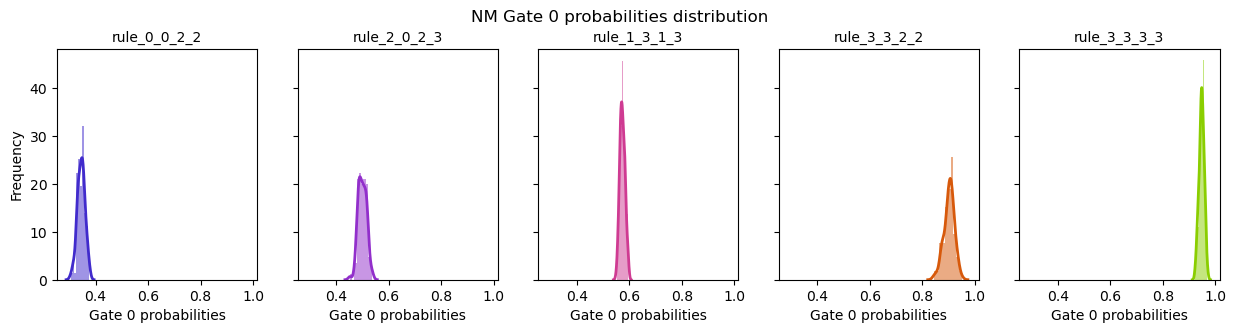

In [64]:
def gate_prob_hists_from_dict(plot_dict, 
                            title,
                            colors = ["#412BCC",
                                    "#922FCB",
                                    "#CF3B92",
                                    "#D7590B",
                                    '#8ACE00',
                                    "#00CE6E"]): 
    num_plots = len(plot_dict)
    fig, axs = plt.subplots(ncols = num_plots, figsize = (num_plots * 3.0, 3.0),
                        sharex=True, sharey=True)
    
    for i, key in enumerate(plot_dict.keys()):
        # plot only p from 1st column, as 2nd column is 1-p
        data = plot_dict[key][:,0]

        sns.histplot(data=data, kde=False, stat='density',bins=10, 
                    color=colors[i],alpha=0.5,edgecolor=None, ax = axs[i])
        sns.kdeplot(data=data, color=colors[i], alpha=1, lw=2.0, ax=axs[i])
        axs[i].set_title(f'rule_{key}',fontsize=10,pad=5)
        axs[i].set_xlabel(f'Gate 0 probabilities',fontsize=10)

    axs[0].set_ylabel('Frequency')
    fig.suptitle(title,y=1.01)

gate_prob_hists_from_dict(NM_gate_probs_dict,title='NM Gate 0 probabilities distribution')
plt.savefig(f'{FIGURES_FILEPATH}NM_gate_probs_separate.png',dpi=150)

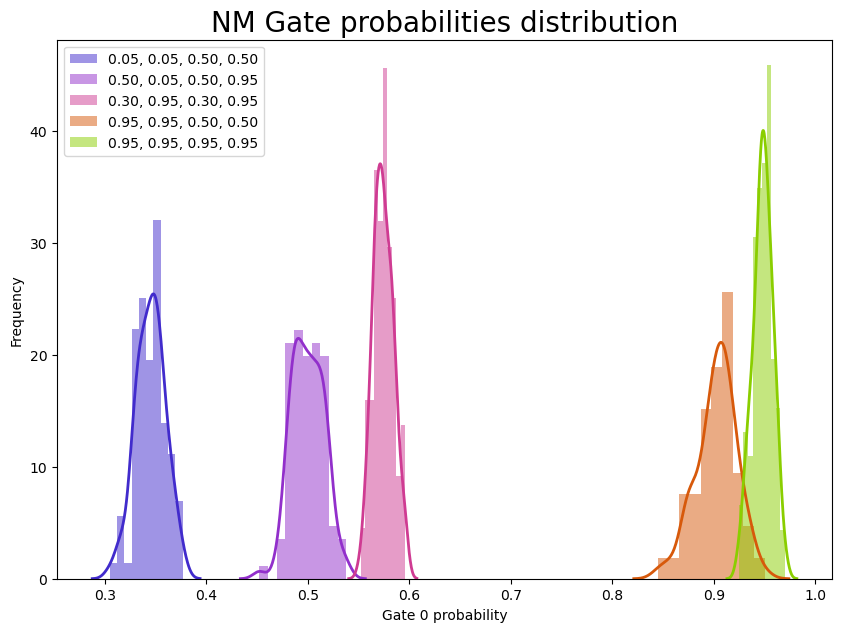

In [57]:
def gate_prob_overlay_hist_from_dict(plot_dict, 
                                    title, 
                                    save_name=None,
                                    probabilities = [0.05, 0.3, 0.5, 0.95],
                                    colors = ["#412BCC",
                                            "#922FCB",
                                            "#CF3B92",
                                            "#D7590B",
                                            '#8ACE00',
                                            "#00CE6E"]): 
    num_plots = len(plot_dict)
    fig, ax = plt.subplots(1,1, figsize = (10,7))

    rule_num_to_prob = {str(i): x for i, x in enumerate(probabilities)}
    
    for i,key in enumerate(plot_dict.keys()):
        # plot only p from 1st column, as 2nd column is 1-p
        data = plot_dict[key][:,0]

        sns.histplot(data=data, kde=False, stat='density',bins=10, 
                    color=colors[i], alpha = 0.5, edgecolor=None, 
                    ax = ax,
                    label=', '.join([f'{rule_num_to_prob[x]:.2f}' for x in key.split('_')])
        )
        sns.kdeplot(data=data, 
                    color=colors[i], alpha=1, lw=2.0, 
                    ax=ax
                    )

    plt.title(title,fontsize=20)
    plt.legend(fontsize=10)
    ax.set_xlabel('Gate 0 probability')
    ax.set_ylabel('Frequency')

    if save_name:
        plt.savefig(f'{FIGURES_FILEPATH}{save_name}.png',dpi=200)
    plt.show()

gate_prob_overlay_hist_from_dict(NM_gate_probs_dict,
                        title='NM Gate probabilities distribution',
                        save_name='NM_gate_probs_hist_combined')